### GP Regression Baseline

Load in-context learning data D and fit a GP to this data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern
from sklearn.linear_model import LogisticRegression

import torch

In [2]:
data_path = "ToyRegression/logistic_regression_data/logistic_regression_1.csv"

D = pd.read_csv(data_path)

In [3]:
np.random.seed(0)

In [4]:
x = D['x1'].values
y = D['y'].values

X_test = np.linspace(-10, 10, 1000).reshape(-1, 1)

In [5]:
gpc = GaussianProcessClassifier(kernel=1.0 * RBF(length_scale=1.5))

gpc.fit(x.reshape(-1, 1), y)

GaussianProcessClassifier(kernel=1**2 * RBF(length_scale=1.5))

In [6]:
# Model with gptorch

import gpytorch

class GPClassificationModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

/data2/users/ij23/micromamba_root/micromamba/envs/vpud/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
x_train = torch.tensor(x).float()
y_train = torch.tensor(y).float()


In [8]:
likelihood = gpytorch.likelihoods.BernoulliLikelihood()

inducing_points = x_train[::5]  # A subset of training points as inducing points
model = GPClassificationModel(inducing_points)

# Use Stochastic Variational Gaussian Process (SVGP)
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y_train.size(0))

training_iterations = 1000
for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(x_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f"Iter {i}/{training_iterations} - Loss: {loss.item():.3f}")

Iter 0/1000 - Loss: 0.908
Iter 10/1000 - Loss: 0.529
Iter 20/1000 - Loss: 0.498
Iter 30/1000 - Loss: 0.485
Iter 40/1000 - Loss: 0.480
Iter 50/1000 - Loss: 0.478
Iter 60/1000 - Loss: 0.476
Iter 70/1000 - Loss: 0.475
Iter 80/1000 - Loss: 0.474
Iter 90/1000 - Loss: 0.473
Iter 100/1000 - Loss: 0.472
Iter 110/1000 - Loss: 0.472
Iter 120/1000 - Loss: 0.471
Iter 130/1000 - Loss: 0.471
Iter 140/1000 - Loss: 0.471
Iter 150/1000 - Loss: 0.470
Iter 160/1000 - Loss: 0.470
Iter 170/1000 - Loss: 0.470
Iter 180/1000 - Loss: 0.470
Iter 190/1000 - Loss: 0.469
Iter 200/1000 - Loss: 0.469
Iter 210/1000 - Loss: 0.469
Iter 220/1000 - Loss: 0.469
Iter 230/1000 - Loss: 0.469
Iter 240/1000 - Loss: 0.469
Iter 250/1000 - Loss: 0.469
Iter 260/1000 - Loss: 0.469
Iter 270/1000 - Loss: 0.469
Iter 280/1000 - Loss: 0.469
Iter 290/1000 - Loss: 0.468
Iter 300/1000 - Loss: 0.468
Iter 310/1000 - Loss: 0.468
Iter 320/1000 - Loss: 0.468
Iter 330/1000 - Loss: 0.468
Iter 340/1000 - Loss: 0.468
Iter 350/1000 - Loss: 0.468
Ite

In [9]:
# logistic regression classifier


lr = LogisticRegression()

lr.fit(x.reshape(-1, 1), y)


LogisticRegression()

In [10]:
y_pred_prob = gpc.predict_proba(X_test)
y_pred_prob_lr = lr.predict_proba(X_test)

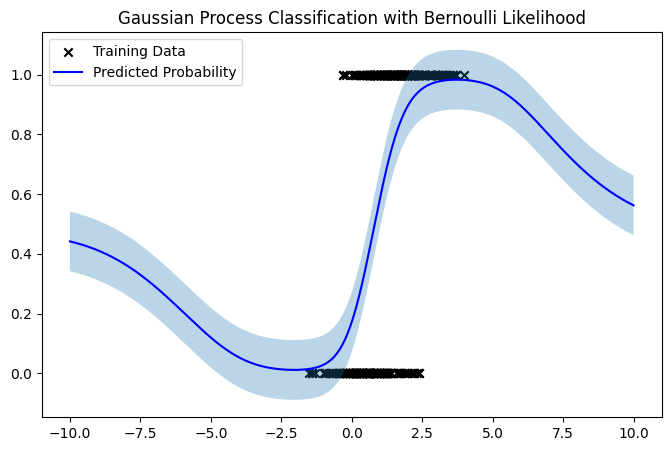

In [11]:
model.eval()
likelihood.eval()

x_test_tensor = torch.tensor(X_test).float()
with torch.no_grad():
    preds = model(x_test_tensor)
    pred_probs = likelihood(preds).probs  # Convert latent function outputs to probabilities

# Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(x_train.numpy(), y_train.numpy(), label="Training Data", c='black', marker='x')
plt.plot(x_test_tensor.numpy(), pred_probs.numpy(), label="Predicted Probability", color='blue')
plt.fill_between(x_test_tensor.flatten().numpy(), pred_probs.numpy()-0.1, pred_probs.numpy()+0.1, alpha=0.3)
plt.legend()
plt.title("Gaussian Process Classification with Bernoulli Likelihood")
plt.show()

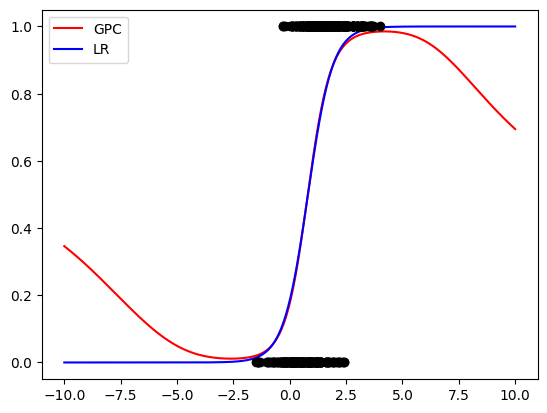

In [12]:
plt.figure()
plt.plot(X_test, y_pred_prob[:, 1], 'r', label='GPC')
plt.plot(X_test, y_pred_prob_lr[:, 1], 'b', label='LR')
plt.scatter(x, y, color='black', zorder=10)
plt.legend()
plt.show()